In [30]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("harishkumardatalab/food-image-classification-dataset")

print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:09<00:00, 191MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/harishkumardatalab/food-image-classification-dataset/versions/1


In [31]:
# Путь к папке с изображениями
dataset_path = path + '/Food Classification dataset'
# Список папок (каждая папка - отдельный класс еды)
class_folders = os.listdir(dataset_path)
print("Найдено классов:", len(class_folders))

Найдено классов: 34


In [32]:
all_images = []  # список списков путей
for folder in class_folders:
    folder_path = os.path.join(dataset_path, folder)
    # Получаем все файлы в папке (изображения)
    files = list(Path(folder_path).glob('*'))
    all_images.append(files)

In [33]:
# 3. ЗАГРУЖАЕМ ИЗОБРАЖЕНИЯ В ПАМЯТЬ (БЕЗ ОГРАНИЧЕНИЙ)
# Теперь мы прочитаем все изображения, приведём к одному размеру и нормализуем.
data_x = []   # здесь будут массивы изображений
data_y = []   # здесь будут метки классов (числа от 0 до 33)

In [34]:
# Задаём размер, до которого будем сжимать все картинки
IMG_SIZE = (120, 120)

# Проходим по каждому классу
for class_index, image_path_list in enumerate(all_images):
    print(f"Загружаем класс {class_index}...")
    for img_path in image_path_list:
        try:
            # Открываем изображение
            img = Image.open(img_path)
            # Переводим в RGB (на всякий случай, если есть ч/б или PNG с прозрачностью)
            img = img.convert('RGB')
            # Меняем размер
            img = img.resize(IMG_SIZE)
            # Превращаем в массив numpy и нормализуем (делим на 255, чтобы значения были от 0 до 1)
            img_array = np.array(img) / 255.0
            # Добавляем в общий список
            data_x.append(img_array)
            data_y.append(class_index)
        except Exception as e:
            # Если какое-то изображение повреждено, пропускаем его
            print(f"Ошибка с файлом {img_path}: {e}")

Загружаем класс 0...
Загружаем класс 1...
Загружаем класс 2...
Загружаем класс 3...
Загружаем класс 4...
Загружаем класс 5...
Загружаем класс 6...
Загружаем класс 7...
Загружаем класс 8...
Загружаем класс 9...
Загружаем класс 10...
Загружаем класс 11...
Загружаем класс 12...
Загружаем класс 13...
Загружаем класс 14...
Загружаем класс 15...
Загружаем класс 16...
Загружаем класс 17...
Загружаем класс 18...
Загружаем класс 19...
Загружаем класс 20...
Загружаем класс 21...
Загружаем класс 22...
Загружаем класс 23...
Загружаем класс 24...
Загружаем класс 25...
Загружаем класс 26...
Загружаем класс 27...
Загружаем класс 28...
Загружаем класс 29...
Загружаем класс 30...
Загружаем класс 31...
Загружаем класс 32...
Загружаем класс 33...


In [35]:
data_x = np.array(data_x)
data_y = np.array(data_y)

print("Итоговая форма данных:", data_x.shape)
print("Количество изображений:", len(data_x))
print("Распределение по классам (сколько картинок в каждом классе):")
unique, counts = np.unique(data_y, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  Класс {cls}: {cnt} изображений")

Итоговая форма данных: (23873, 120, 120, 3)
Количество изображений: 23873
Распределение по классам (сколько картинок в каждом классе):
  Класс 0: 279 изображений
  Класс 1: 376 изображений
  Класс 2: 1000 изображений
  Класс 3: 214 изображений
  Класс 4: 269 изображений
  Класс 5: 334 изображений
  Класс 6: 307 изображений
  Класс 7: 1500 изображений
  Класс 8: 344 изображений
  Класс 9: 1000 изображений
  Класс 10: 327 изображений
  Класс 11: 323 изображений
  Класс 12: 244 изображений
  Класс 13: 1500 изображений
  Класс 14: 1000 изображений
  Класс 15: 245 изображений
  Класс 16: 1500 изображений
  Класс 17: 275 изображений
  Класс 18: 302 изображений
  Класс 19: 1000 изображений
  Класс 20: 144 изображений
  Класс 21: 1500 изображений
  Класс 22: 1500 изображений
  Класс 23: 1548 изображений
  Класс 24: 288 изображений
  Класс 25: 1000 изображений
  Класс 26: 273 изображений
  Класс 27: 295 изображений
  Класс 28: 305 изображений
  Класс 29: 1500 изображений
  Класс 30: 1500 изобра

In [36]:
# Сначала отделим тестовую выборку (15% от всех данных)
x_temp, x_test, y_temp, y_test = train_test_split(
    data_x, data_y,
    test_size=0.15,
    random_state=42,
    stratify=data_y   # сохраняем пропорции классов
)

In [37]:
# Из оставшихся 85% выделим валидационную выборку (примерно 15% от исходных, т.е. 15/85 ≈ 17.6% от временной)
# Можно просто взять 0.176 от временной выборки
x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp,
    test_size=0.176,   # 0.176 * 0.85 ≈ 0.15 от исходных
    random_state=42,
    stratify=y_temp
)

print(f"Обучающая выборка: {x_train.shape}")
print(f"Валидационная выборка: {x_val.shape}")
print(f"Тестовая выборка: {x_test.shape}")

Обучающая выборка: (16720, 120, 120, 3)
Валидационная выборка: (3572, 120, 120, 3)
Тестовая выборка: (3581, 120, 120, 3)


In [38]:
# 5. АУГМЕНТАЦИЯ ДАННЫХ (чтобы увеличить разнообразие и бороться с переобучением)
# Создаём генератор, который будет на лету применять случайные преобразования к изображениям
train_datagen = ImageDataGenerator(
    rotation_range=20,       # случайный поворот на ±20 градусов
    width_shift_range=0.2,   # случайный сдвиг по ширине до 20%
    height_shift_range=0.2,  # случайный сдвиг по высоте до 20%
    horizontal_flip=True,    # случайное отражение по горизонтали
    zoom_range=0.2           # случайное приближение/отдаление до 20%
)

In [39]:
# Для валидации и теста аугментация не нужна, только нормализация (она уже сделана)
# Поэтому создаём "пустой" генератор, который ничего не меняет
val_test_datagen = ImageDataGenerator()

In [40]:
# Связываем генераторы с нашими данными
# flow() создаёт итератор, который будет выдавать батчи изображений
batch_size = 32

train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_test_datagen.flow(
    x_val, y_val,
    batch_size=batch_size,
    shuffle=False
)


In [41]:
# 6. СОЗДАНИЕ МОДЕЛИ (простая, но эффективная свёрточная сеть)
model = models.Sequential()

# Входной слой (указываем размер картинки)
model.add(layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3)))

# Первый блок: две свёртки + пулинг
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Второй блок: две свёртки + пулинг
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Третий блок: две свёртки + пулинг
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Превращаем карту признаков в вектор
model.add(layers.Flatten())

# Полносвязные слои
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))   # отключаем случайно 50% нейронов для борьбы с переобучением
model.add(layers.Dense(34, activation='softmax'))  # 34 класса, softmax даёт вероятности

# Печатаем структуру модели
model.summary()

# 7. КОМПИЛЯЦИЯ МОДЕЛИ
# Используем оптимизатор Adam с уменьшенной скоростью обучения (0.0001 вместо 0.001)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 8. КОЛЛБЭК (ранняя остановка)
# Если в течение 15 эпох точность на валидации не улучшается, обучение прекратится,
# и восстановятся лучшие веса.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 120, 120, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 120, 120, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 60, 60, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 60, 60, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 30, 30, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 15, 15, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     7,373,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 34)             │         8,738 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,668,802 (29.25 MB)

 Trainable params: 7,668,802 (29.25 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 65s 115ms/step - accuracy: 0.0730 - loss: 3.3278 - val_accuracy: 0.1442 - val_loss: 3.0382
Epoch 2/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.1348 - loss: 3.0821 - val_accuracy: 0.1870 - val_loss: 2.8034
Epoch 3/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.1649 - loss: 2.9383 - val_accuracy: 0.2315 - val_loss: 2.7053
Epoch 4/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.1909 - loss: 2.8295 - val_accuracy: 0.2794 - val_loss: 2.5473
Epoch 5/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.2105 - loss: 2.7411 - val_accuracy: 0.2766 - val_loss: 2.5260
Epoch 6/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.2383 - loss: 2.6832 - val_accuracy: 0.3010 - val_loss: 2.4414
Epoch 7/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 99ms/step - accuracy: 0.2495 - loss: 2.6258 - val_accuracy: 0.3231 - val_loss: 2.3616
Epoch 8/200
523/523 ━━━━━━━━━━━━━━━━━━━━ 52s 100ms/step - accuracy: 0.2532 - los

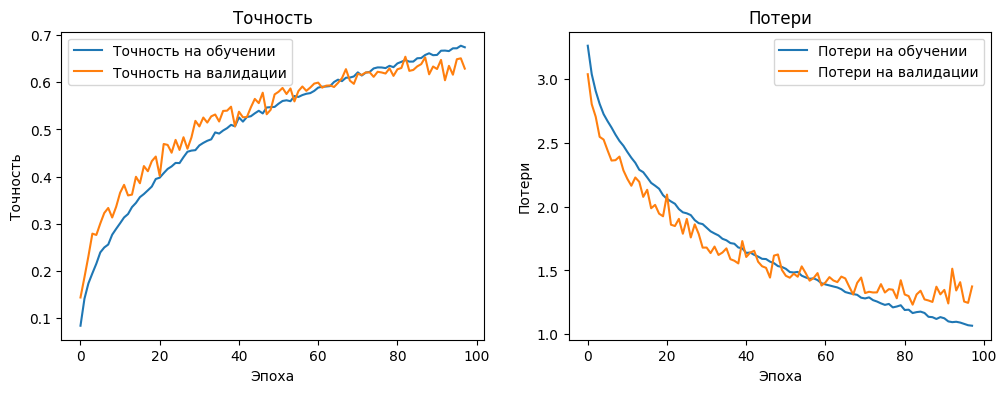

In [42]:
# 9. ОБУЧЕНИЕ МОДЕЛИ
# Обучаем на генераторе с аугментацией, валидацию проводим на обычных данных
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=200,                # максимум эпох, но ранняя остановка сработает раньше
    callbacks=[early_stop],
    verbose=1
)

# 10. ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f}")

# 11. ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.title('Потери')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.show()


Точность на тестовой выборке: 0.6420


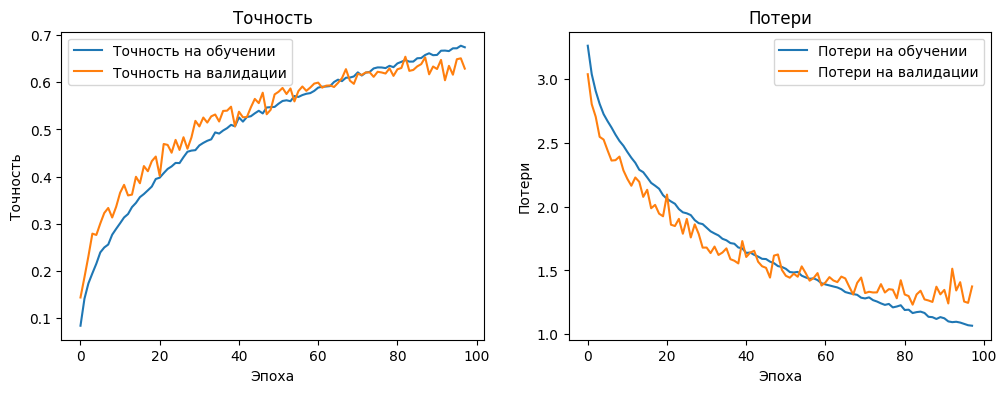

In [44]:
# 10. ОЦЕНКА НА ТЕСТОВОЙ ВЫБОРКЕ
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nТочность на тестовой выборке: {test_acc:.4f}")

# 11. ВИЗУАЛИЗАЦИЯ ПРОЦЕССА ОБУЧЕНИЯ
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Точность на обучении')
plt.plot(history.history['val_accuracy'], label='Точность на валидации')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Точность')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Потери на обучении')
plt.plot(history.history['val_loss'], label='Потери на валидации')
plt.title('Потери')
plt.xlabel('Эпоха')
plt.ylabel('Потери')
plt.legend()
plt.show()